In [10]:
import os
import json
import hydra
from omegaconf import OmegaConf
from data.lvb import LongVideoBench

def plot_window_results(results_path: str):
    with open(results_path, "r") as f:
        results = json.load(f)
    return results


def parse_answer(answer: str) -> str:
    """Parse the agent's answer to extract the choice number."""
    import re
    if answer is None:
        return ""
    # Try to find a number in the answer
    numbers = re.findall(r'\d+', answer)
    if numbers:
        return numbers[0]  # Return the first number found
    return ""


def calculate_accuracy(results: list[dict]) -> float:
    """Calculate accuracy by comparing predicted vs ground truth choices."""
    if not results:
        return 0.0
    
    correct = 0
    for result in results:
        pred = parse_answer(result["pred"])
        gt = str(result["gt"])
        if pred == gt:
            correct += 1
    
    return correct / len(results)

dataset_name = "lvb"
windows = [8,10,16,32]
result_paths = [f"../../windowtest/{dataset_name}_{window}/agent_results.json" for window in windows]


config = OmegaConf.load("../../src/vseek/config/retriever/config.yaml")
data_entries = LongVideoBench(config).load_data()
data_entries = {entry["metadata"]["id"]: entry for entry in data_entries}
result_dict = {}


for result_path in result_paths:
    window = int(result_path.split("_")[1].split("/")[0])
    with open(result_path, "r") as f:
        results = json.load(f)
    
    for result in results:
        result["data_entry"] = data_entries[result["question_id"]]
    
    result_dict[window] = results
 
        

    

    


print(result_dict)


{8: [{'video_id': '86CxyhFV9MI', 'question_id': '86CxyhFV9MI_0', 'pred': 'None of the provided options match the subtitles appearing at the same time as the man with black hair, dressed in grey clothes with black sleeves, on stage.', 'gt': '1', 'parsed_pred': '', 'data_entry': {'question': "In the video, which subtitles appear at the same time as the man with black hair, dressed in grey clothes with black sleeves, on stage? here are the candidates: \n0. promisc has come to an end, in and run away countless times, i was just scared, i still\n1. run away countless times, i was just scared, i still and front of our crown, like a world of souls,\n2. promisc has come to an end, in and front of our crown, like a world of souls,\n3. promisc has come to an end, in and captain of the godson, three three three three three three\n It's a multiple choice question. You must choose the correct answer as a number.", 'candidates': ['promisc has come to an end, in and run away countless times, i was ju

Window 8: Accuracy = 0.14
Window 10: Accuracy = 0.13
Window 16: Accuracy = 0.14
Window 32: Accuracy = 0.13


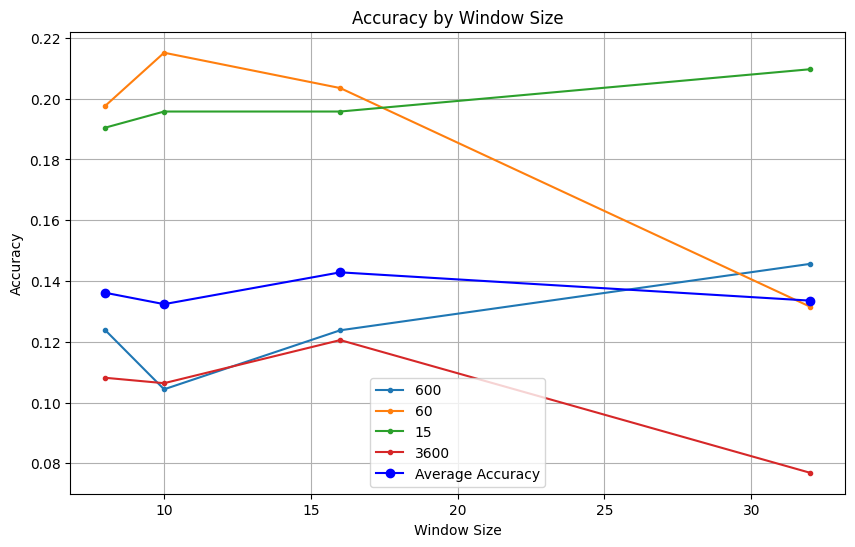

In [18]:
# Plot accuracy by window size

from matplotlib import pyplot as plt


accuracies = []
windows = list(result_dict.keys())
for window, results in result_dict.items():
    acc = calculate_accuracy(results)
    print(f"Window {window}: Accuracy = {acc:.2f}")
    accuracies.append(acc)
    
# Calculate accuracy by duration group in data_entry field per window size

duration_group_accuracies_window = {}
for window, results in result_dict.items():
    duration_groups = {}
    duration_group_accuracies = {}
    for result in results:
        data_entry = result["data_entry"]
        duration_group = data_entry["metadata"]["duration_group"]
        if duration_group not in duration_groups:
            duration_groups[duration_group] = [result]
        else:   
            duration_groups[duration_group].append(result)
    
    for duration_group, result_duration_group in duration_groups.items():
        acc = calculate_accuracy(result_duration_group)
        duration_group_accuracies[duration_group] = acc
    
    duration_group_accuracies_window[window] = duration_group_accuracies


# Structure the data as [duration_group, [accuracies]]
plot_duration_group_accuracies = {
    duration_group: [[],[]] for duration_group in duration_group_accuracies_window[list(duration_group_accuracies_window.keys())[0]].keys()
}
for duration_group in duration_group_accuracies_window[list(duration_group_accuracies_window.keys())[0]].keys():
    for window in duration_group_accuracies_window.keys():
        plot_duration_group_accuracies[duration_group][0].append(window)
        plot_duration_group_accuracies[duration_group][1].append(duration_group_accuracies_window[window][duration_group])

# Plot a line plot for all the average accuracies and the accuracies for each duration group (with correct legend)


plt.figure(figsize=(10, 6))
# I want different colors for each duration group
colors = plt.cm.tab10.colors
for i, duration_group in enumerate(plot_duration_group_accuracies.keys()):
    plt.plot(plot_duration_group_accuracies[duration_group][0], plot_duration_group_accuracies[duration_group][1], marker='.', linestyle='-', color=colors[i], label=f'{duration_group}')
plt.plot(windows, accuracies, marker='o', linestyle='-', color='b', label='Average Accuracy')
# for duration_group in plot_duration_group_accuracies.keys():
#     plt.plot(plot_duration_group_accuracies[duration_group][0], plot_duration_group_accuracies[duration_group][1], marker='o', linestyle='-', color='r', label=f'Duration Group {duration_group}')
plt.xlabel('Window Size')
plt.ylabel('Accuracy')
plt.title('Accuracy by Window Size')
plt.legend()
plt.grid(True)
plt.show()
